In [1]:
import sys
sys.executable

'/home/papinwit/wk2image2cap/img2cap-env/bin/python3'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_optimizer import Lookahead
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
import timm
import numpy as np
import evaluate
from tqdm import tqdm

2025-03-09 09:19:21.862608: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-09 09:19:21.876604: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741486761.891026 3129551 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741486761.895380 3129551 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-09 09:19:21.911982: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [40]:
# === Dataset Configuration === #
dataset_path = "/home/papinwit/wk2image2cap/uwb/preprocess_dataset/train"  # Update with your dataset path
transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
dataset = ImageFolder(root=dataset_path, transform=transforms)

In [41]:
# === Training Configuration === #
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "hf_hub:timm/maxvit_large_tf_224.in1k"

In [42]:
num_epochs = 25
train_batch_size = 8
eval_batch_size = 16
num_accumulate = 4
k_splits = 6
metric = evaluate.load("f1")

# === Cross-validation === #
kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)
all_eval_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"Fold {fold+1} of {k_splits}")

    # === Load Model === #
    model = timm.create_model(model_name, pretrained=True, num_classes=len(dataset.classes)).to(device)

    # === Optimizer and Scheduler === #
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    optimizer = Lookahead(optimizer, alpha=0.5, k=6)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    # === Data Loaders === #
    train_dataset = Subset(dataset, train_idx)
    val_dataset = Subset(dataset, val_idx)
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)

    # === Loss Function === #
    criterion = nn.CrossEntropyLoss()

    # === Logging === #
    info = {
        "metric_train": [],
        "metric_val": [],
        "train_loss": [],
        "val_loss": [],
        "best_metric_val": -999,
    }

    # === Training Loop === #
    for epoch in range(num_epochs):
        train_loss_epoch = []
        val_loss_epoch = []
        train_preds, train_targets = [], []
        val_preds, val_targets = [], []

        model.train()
        for idx, (inputs, targets) in enumerate(tqdm(train_dataloader)):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            # === Gradient Accumulation === #
            if ((idx + 1) % num_accumulate == 0) or (idx + 1 == len(train_dataloader)):
                optimizer.step()
                optimizer.zero_grad()

            train_loss_epoch.append(loss.item())
            train_preds += outputs.argmax(-1).detach().cpu().tolist()
            train_targets += targets.cpu().tolist()

        # === Update Scheduler === #
        scheduler.step()

        # === Validation Loop === #
        model.eval()
        with torch.no_grad():
            for inputs, targets in tqdm(val_dataloader):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss_epoch.append(loss.item())
                val_preds += outputs.argmax(-1).detach().cpu().tolist()
                val_targets += targets.cpu().tolist()

        # === Compute Metrics === #
        metric_train = metric.compute(predictions=train_preds, references=train_targets, average="macro")["f1"]
        metric_val = metric.compute(predictions=val_preds, references=val_targets, average="macro")["f1"]

        # === Logging === #
        info["metric_train"].append(metric_train)
        info["metric_val"].append(metric_val)
        info["train_loss"].append(np.mean(train_loss_epoch))
        info["val_loss"].append(np.mean(val_loss_epoch))

        # === Save Best Model === #
        if metric_val > info["best_metric_val"]:
            print("New Best Score!")
            info["best_metric_val"] = metric_val
            torch.save(model.state_dict(), f"checkpoint_fold{fold}.pt")

        print(f"Fold: {fold} | Epoch: {epoch} | F1 Score: {metric_val:.4f} | "
              f"Train Loss: {np.mean(train_loss_epoch):.4f} | Val Loss: {np.mean(val_loss_epoch):.4f}")

    all_eval_scores.append(info["best_metric_val"])

Fold 1 of 6


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  3.75it/s]


New Best Score!
Fold: 0 | Epoch: 0 | F1 Score: 0.4740 | Train Loss: 1.4553 | Val Loss: 1.2751


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  3.64it/s]


New Best Score!
Fold: 0 | Epoch: 1 | F1 Score: 0.5753 | Train Loss: 0.9869 | Val Loss: 0.9817


...

Fold: 5 | Epoch: 22 | F1 Score: 0.7753 | Train Loss: 0.0016 | Val Loss: 0.8496


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  6.61it/s]


Fold: 5 | Epoch: 23 | F1 Score: 0.7664 | Train Loss: 0.0017 | Val Loss: 0.8394


100%|█████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:01<00:00,  6.62it/s]

Fold: 5 | Epoch: 24 | F1 Score: 0.7485 | Train Loss: 0.0014 | Val Loss: 0.8627


/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 0: 1


Fold: 0 - Confusion Matrix



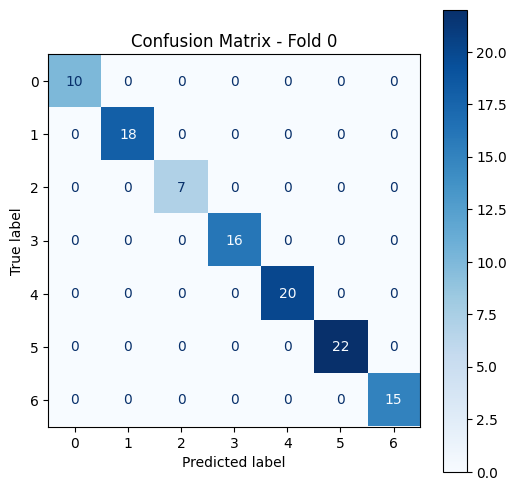

/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 1: 1


Fold: 1 - Confusion Matrix



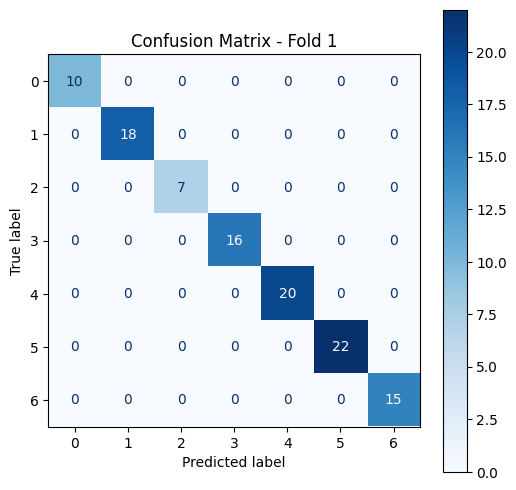

/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 2: 1


Fold: 2 - Confusion Matrix



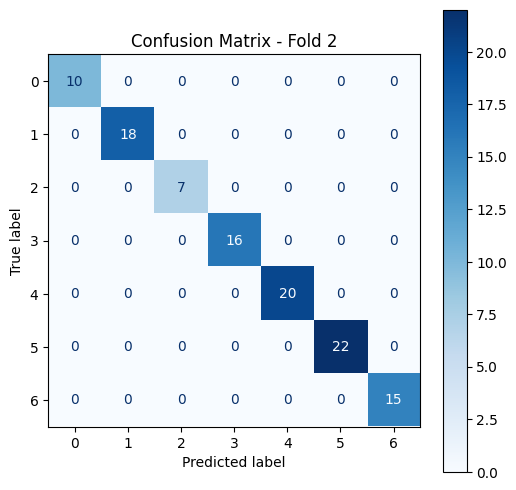

/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 3: 1


Fold: 3 - Confusion Matrix



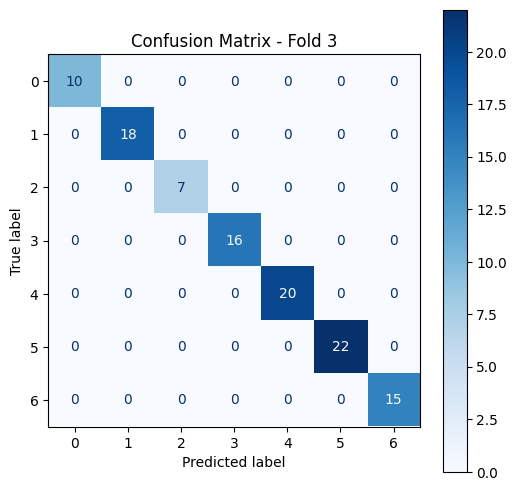

/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 4: 1


Fold: 4 - Confusion Matrix



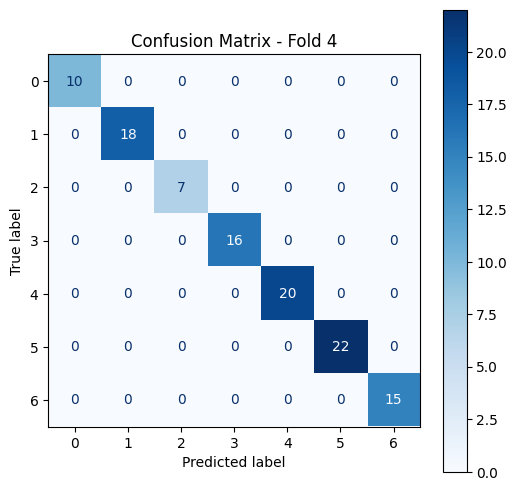

/tmp/ipykernel_3129551/448235486.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))
Evaluating Fold 5: 1


Fold: 5 - Confusion Matrix



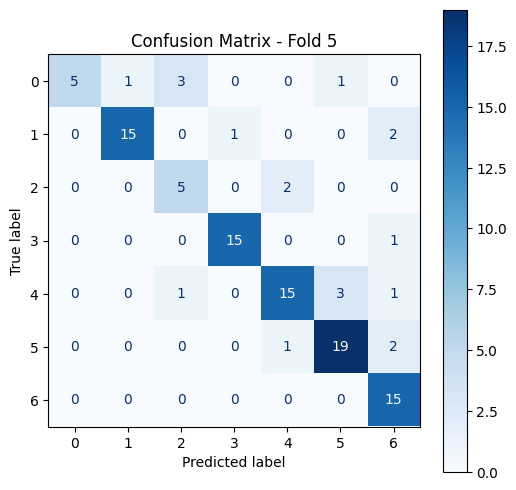

In [43]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

# === Cross-validation Evaluation === #
for fold in range(k_splits):
    predictions = []
    references = []

    # Reinitialize the model
    model = timm.create_model(model_name, pretrained=False, num_classes=len(dataset.classes)).to(device)

    # Load saved weights
    model_path = f"checkpoint_fold{fold}.pt"  # Ensure this path is correct
    model.load_state_dict(torch.load(model_path, map_location=device))

    model.eval()

    # Use the same validation set as in training
    val_dataset = Subset(dataset, val_idx)  # Ensure correct val_idx for each fold
    val_dataloader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)

    with torch.no_grad():
        for batch in tqdm(val_dataloader, desc=f"Evaluating Fold {fold}"):
            inputs, targets = batch
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            predictions += outputs.argmax(-1).detach().cpu().tolist()
            references += targets.cpu().tolist()

    # Print results
    print(f"\nFold: {fold} - Confusion Matrix\n")

    # Generate Confusion Matrix
    cm = confusion_matrix(references, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Plot Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()

In [44]:
import torch
import timm
import os
import numpy as np
from torchvision import transforms as T
from PIL import Image
from collections import Counter

# === Configuration === #
test_dir = "/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/"
model_name = "hf_hub:timm/maxvit_large_tf_224.in1k"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_folds = 5  # Number of KFold splits
class_names = dataset.classes  # Get class names from training dataset

# === Test Transforms === #
test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# === Load Models === #
models = []
for fold in range(num_folds):
    model = timm.create_model(model_name, pretrained=False, num_classes=len(class_names)).to(device)
    checkpoint_path = f"checkpoint_fold{fold}.pt"
    
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        models.append(model)
    else:
        print(f"Warning: Checkpoint {checkpoint_path} not found!")

# === Load Test Images === #
test_files = sorted([os.path.join(test_dir, f) for f in os.listdir(test_dir) if f.endswith(".png")])

final_predictions = []

# === Prediction Loop === #
for image_path in test_files:
    image = Image.open(image_path).convert("RGB")
    input_tensor = test_transforms(image).unsqueeze(0).to(device)

    predictions = []
    
    # === Get predictions from all models === #
    with torch.no_grad():
        for model in models:
            output = model(input_tensor)
            pred_label = output.argmax(dim=1).item()
            predictions.append(pred_label)

    # === Majority Voting === #
    final_label = Counter(predictions).most_common(1)[0][0]
    final_predictions.append((image_path, class_names[final_label]))

# === Print Results === #
for img_path, label in final_predictions:
    print(f"{img_path} -> Predicted Label: {label}")

/tmp/ipykernel_3129551/1756081205.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device))


/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/0235320b-1bad-4422-98d5-5c14cf9ddd59.png -> Predicted Label: 2
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/04079ed6-01e6-42bc-b8a0-b30ea9446bf5.png -> Predicted Label: 4
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/052d35a0-25d8-4eea-9827-2f8d18b6aa99.png -> Predicted Label: 6
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/0613da04-d5f9-4989-b1be-4ce1f3c06dc4.png -> Predicted Label: 0
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/07159490-a60b-4512-9538-4357d145f5ff.png -> Predicted Label: 6
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/09726b64-488b-48dc-b44a-87a0c3a8f6a3.png -> Predicted Label: 6
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/0b546103-eb69-4778-8ce7-38c1f69c9217.png -> Predicted Label: 3
/home/papinwit/wk2image2cap/uwb/preprocess_dataset/test/0bf17f5b-f52c-42ef-b771-0187588ad2de.png -> Predicted Label: 4
/home/papinwit/wk2image2cap/uwb/preprocess_datas

In [45]:
final_predictions[0][0].split('/')[-1].replace('.png','')

'0235320b-1bad-4422-98d5-5c14cf9ddd59'

In [46]:
predict_dict = dict()
for img_path, label in final_predictions:
    k = img_path.split('/')[-1].replace('.png','')
    predict_dict[k] = label
predict_dict

{'0235320b-1bad-4422-98d5-5c14cf9ddd59': '2',
 '04079ed6-01e6-42bc-b8a0-b30ea9446bf5': '4',
 '052d35a0-25d8-4eea-9827-2f8d18b6aa99': '6',
 '0613da04-d5f9-4989-b1be-4ce1f3c06dc4': '0',
 '07159490-a60b-4512-9538-4357d145f5ff': '6',
 '09726b64-488b-48dc-b44a-87a0c3a8f6a3': '6',
 '0b546103-eb69-4778-8ce7-38c1f69c9217': '3',
 '0bf17f5b-f52c-42ef-b771-0187588ad2de': '4',
 '0d097254-9d9a-4348-bcda-73b534ff27c9': '0',
 '11cd15be-5674-4b46-900b-1a38dda972c6': '1',
 '158922c9-ac47-415e-94c2-d9adcfbe509c': '5',
 '1589af85-8afe-43c3-a928-4c44b52164ff': '6',
 '15e8312f-b7b8-4291-8258-1e388c71cd88': '2',
 '17445f56-bd54-43f0-9560-db427817b8e6': '4',
 '18e0199f-a362-4536-91a4-4c6812a50e26': '3',
 '1a909767-4f53-4488-b926-9b9cd2dcb7ee': '0',
 '1bd08fdf-f0cf-4027-a6cd-213269872e2a': '5',
 '1f8145e6-32bb-4dc9-8768-e6e9b1e4aac8': '1',
 '2203b45e-2193-423c-aab9-00ae97474cfe': '5',
 '23811759-e95d-4714-8599-3864f34c4eda': '4',
 '245f7e3a-f32e-41ee-9a6d-c099f5f3f0a1': '4',
 '2471a7eb-af35-4ae7-870e-6650de9f

In [47]:
import pandas as pd
snt = pd.read_csv('/home/papinwit/wk2image2cap/uwb/sample_submission.csv')

In [48]:
snt

,id,class
0,30de3513-93ff-42d8-ad5f-4c93f4a4444c,6.0
1,84e55af1-ae63-4b06-b650-1136d38b691e,4.0
2,2471a7eb-af35-4ae7-870e-6650de9f0c2f,2.0
3,d00e8bdc-79af-4e55-b25a-96ea589b6420,NaN
4,ad9f77bc-5ab6-477d-b760-2f3fc65c14d3,NaN
...,...,...
159,5fce955d-1068-40b3-afc3-111f8c22c9f9,NaN
160,f3a000be-07c9-44ad-8ff0-b89a9a1070dd,NaN
161,84d3963b-cfed-450c-88ab-ca853273d15c,NaN
162,7b36184c-5541-44d9-9200-8057bd3cf4ef,NaN


In [49]:
for i in range(len(snt)):
    snt.iloc[i,1] = predict_dict[snt.iloc[i,0]]

/tmp/ipykernel_3129551/2548031188.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  snt.iloc[i,1] = predict_dict[snt.iloc[i,0]]


In [50]:
snt

,id,class
0,30de3513-93ff-42d8-ad5f-4c93f4a4444c,3
1,84e55af1-ae63-4b06-b650-1136d38b691e,5
2,2471a7eb-af35-4ae7-870e-6650de9f0c2f,4
3,d00e8bdc-79af-4e55-b25a-96ea589b6420,4
4,ad9f77bc-5ab6-477d-b760-2f3fc65c14d3,0
...,...,...
159,5fce955d-1068-40b3-afc3-111f8c22c9f9,3
160,f3a000be-07c9-44ad-8ff0-b89a9a1070dd,4
161,84d3963b-cfed-450c-88ab-ca853273d15c,0
162,7b36184c-5541-44d9-9200-8057bd3cf4ef,6


In [51]:
snt.to_csv('/home/papinwit/wk2image2cap/uwb/uwb5.csv', index=False)